BrainTumorDetection/

│

├── dataset/

│     ├── Training/

│     ├── Testing/

│

├── notebooks/

│

├── models/

│

├── app.py

├── train.py

├── predict.py

├── preprocess.py

├── requirements.txt

├── README.md

└── images/

In [31]:
# Install Libraries
!pip install tensorflow
!pip install opencv-python
!pip install matplotlib
!pip install scikit-learn
!pip install pillow
!pip install streamlit

**Import Libraries**

In [32]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D

from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt

import numpy as np

**Data Preprocessing**

In [33]:
# Image Augmentation
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)


**Mount the Google Drive**

**Define Paths**

In [34]:
train_path = "Training"
test_path = "Testing"

**Create ImageDataGenerator**

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

**Training Generator**

In [36]:
import os

print("Current folder:", os.getcwd())
print("Training exists:", os.path.exists("Training"))
print("Testing exists:", os.path.exists("Testing"))
print(os.listdir())

Current folder: /Users/shreyanshsrivastav/Desktop/brain
Training exists: True
Testing exists: True
['test_model.py', '.DS_Store', 'requirements.txt', 'brain_tumor_project.ipynb', 'Training', 'Testing', '.venv', 'app.py', '.ipynb_checkpoints', 'brain_tumor_cn.keras']


In [37]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 2297 images belonging to 4 classes.


**Validation Generator**

In [38]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 573 images belonging to 4 classes.


**Test Generator (used after training)**

In [39]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 394 images belonging to 4 classes.


**Load Dataset**

In [40]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="training"

)

Found 2297 images belonging to 4 classes.


In [41]:
validation_generator = train_datagen.flow_from_directory(

    test_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="validation"

)

Found 78 images belonging to 4 classes.


**Check Classes**

In [42]:
print(train_generator.class_indices)

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


**CNN Model**

In [43]:
# Build CNN
model = Sequential()

model.add(

Conv2D(

32,

(3,3),

activation="relu",

input_shape=(224,224,3)

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(

Conv2D(

64,

(3,3),

activation="relu"

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(

Conv2D(

128,

(3,3),

activation="relu"

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(4,activation="softmax"))

/Users/shreyanshsrivastav/Desktop/brain/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Model Summary**

In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**Model Compilation**

In [45]:
# Compile
model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)

**Model Training**

In [46]:
# Train
history = model.fit(

train_generator,

epochs=10,

validation_data=validation_generator

)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 511ms/step - accuracy: 0.4632 - loss: 1.2516 - val_accuracy: 0.3205 - val_loss: 1.7177
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 546ms/step - accuracy: 0.5842 - loss: 0.9443 - val_accuracy: 0.3077 - val_loss: 1.9842
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 573ms/step - accuracy: 0.6491 - loss: 0.8318 - val_accuracy: 0.3077 - val_loss: 2.3721
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 49s 673ms/step - accuracy: 0.6865 - loss: 0.7414 - val_accuracy: 0.3974 - val_loss: 2.4833
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 690ms/step - accuracy: 0.7048 - loss: 0.7134 - val_accuracy: 0.3590 - val_loss: 2.4866
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 48s 661ms/step - accuracy: 0.7236 - loss: 0.6696 - val_accuracy: 0.3333 - val_loss: 2.0406
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 49s 682ms/step - accuracy: 0.7462 - loss: 0.5930 - val_accuracy: 0.4487 - val_loss: 2.1601
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 620ms/step - accuracy: 0.7614 - loss: 0.5691 - val_accu

**Performance**

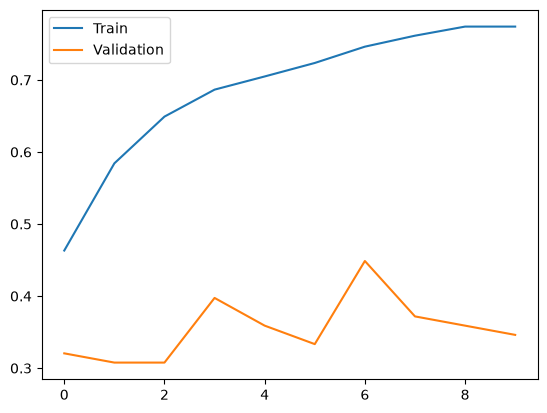

In [47]:
# Plot Accuracy
plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.show()

**Plot Loss**

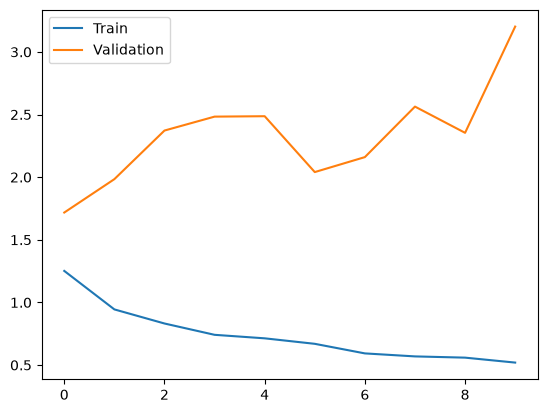

In [48]:
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.show()

**Evaluate**

In [49]:
loss,accuracy=model.evaluate(validation_generator)

print(accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.3974 - loss: 2.9780
0.39743590354919434


**Save Model**

In [50]:
model.save("brain_tumor_model.keras")

**Prediction**

In [51]:
# Load Model
from tensorflow.keras.models import load_model

model=load_model("brain_tumor_model.keras")

**Read Image**

In [52]:
from tensorflow.keras.preprocessing import image

img=image.load_img(

"/content/drive/MyDrive/Brain_Tumor/Training/Multiple-Views-Of-Brain-MRI-Results-1024x499.webp",

target_size=(224,224)

)

img=image.img_to_array(img)

img=img/255

img=np.expand_dims(img,axis=0)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Brain_Tumor/Training/Multiple-Views-Of-Brain-MRI-Results-1024x499.webp'

**Prediction**

In [ ]:
prediction=model.predict(img)

classes=["Glioma",

"Meningioma",

"No Tumor",

"Pituitary"]

print(classes[np.argmax(prediction)])

**Upload MRI**

In [ ]:
import streamlit as st

uploaded_file = st.file_uploader(

"Upload MRI",

type=["jpg","png","jpeg"]

)

**Display Image**

**Predict**

In [ ]:
if st.button("Predict"):

    prediction=model.predict(img)

    st.success(

    classes[np.argmax(prediction)]

    )

**Confidence**

In [ ]:
confidence=np.max(prediction)*100

st.write(

f"Confidence : {confidence:.2f}%"

)

In [53]:
import os

model.save("brain_tumor_model.keras")

print(os.path.exists("brain_tumor_model.keras"))
print(os.path.isdir("brain_tumor_model.keras"))

True
False
